In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Churn_Modelling.csv")

In [3]:
df.shape

(10000, 14)

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

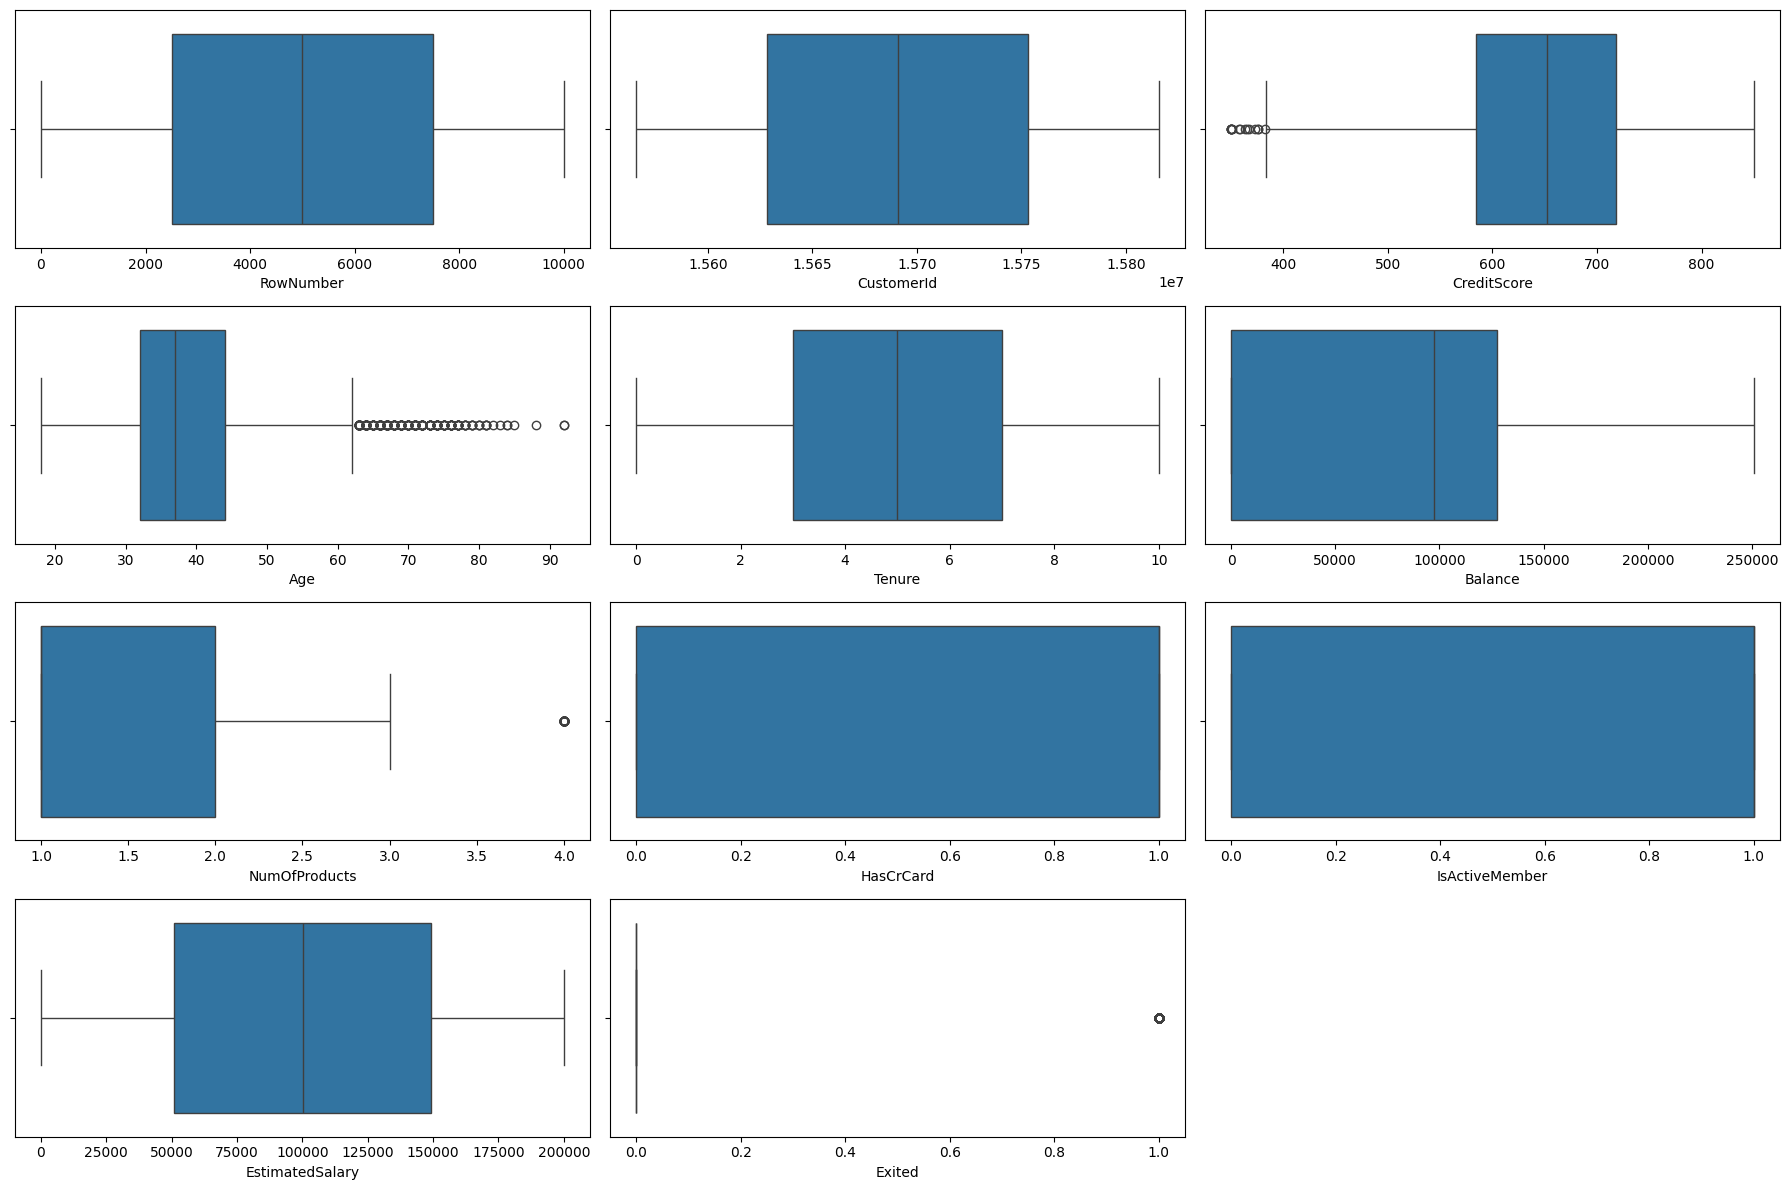

In [8]:
plt.figure(figsize=(18,12))
c=1
for i in df.describe().columns:
    plt.subplot(4,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

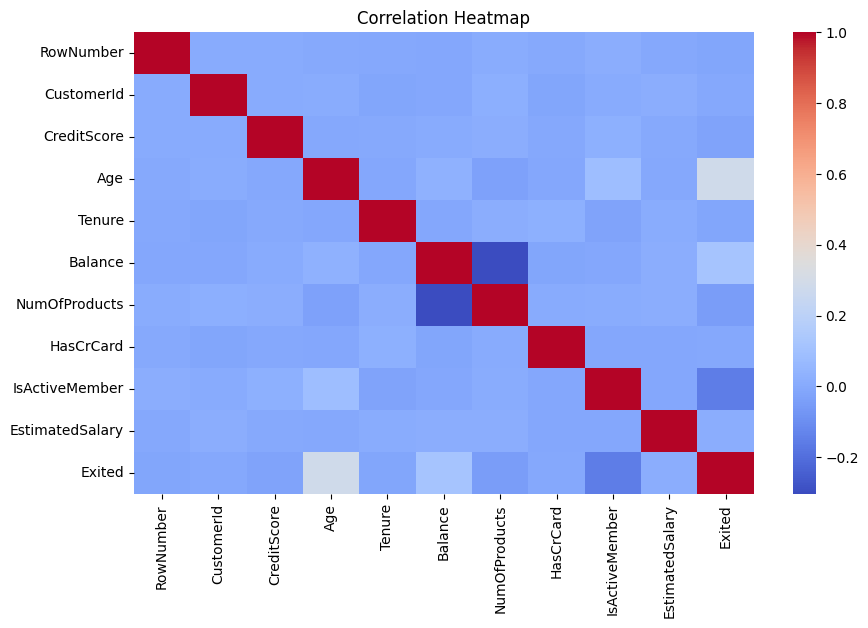

In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [11]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)

Lower bound for outliers: 383.0
Upper bound for outliers: 919.0

Outliers in CreditScore after replacement:


,CreditScore


Total number of outliers after replacement: 0


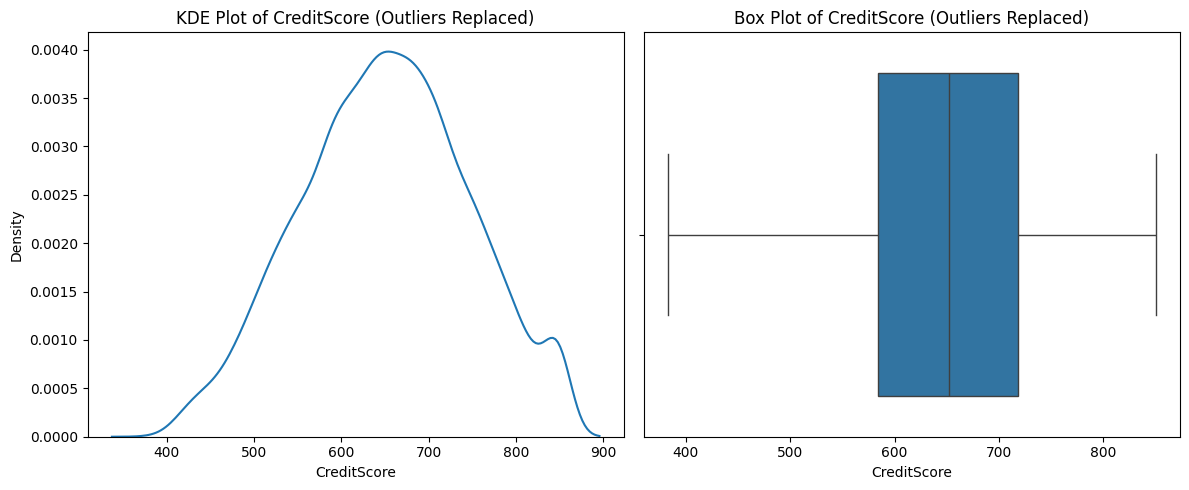

In [12]:
# Calculate Q1, Q3, and IQR for CreditScore
Q1 = df['CreditScore'].quantile(0.25)
Q3 = df['CreditScore'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mean=df['CreditScore'].mean().round().astype(int)

# Replace outliers with the mean value 'mean'
df['CreditScore'] = np.where(df['CreditScore'] < lower_bound,mean,df['CreditScore'])
df['CreditScore'] = np.where(df['CreditScore'] > upper_bound,mean,df['CreditScore'])

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

# Display outliers (should be empty or very few after replacement)
outliers_after_replacement = df[(df['CreditScore'] < lower_bound) | (df['CreditScore'] > upper_bound)]
print("\nOutliers in CreditScore after replacement:")
display(outliers_after_replacement[['CreditScore']].head())
print(f"Total number of outliers after replacement: {len(outliers_after_replacement)}")

# Visualize the distribution after outlier treatment using KDE plot and box plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(df['CreditScore'])
plt.title('KDE Plot of CreditScore (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['CreditScore'])
plt.title('Box Plot of CreditScore (Outliers Replaced)')
plt.tight_layout()
plt.show()

Lower bound for Age outliers: 14.0
Upper bound for Age outliers: 62.0

Outliers in Age before replacement:


,Age
58,66
85,75
104,65
158,73
181,65


Total number of outliers before replacement: 359

Outliers in Age after replacement:


,Age


Total number of outliers after replacement: 0


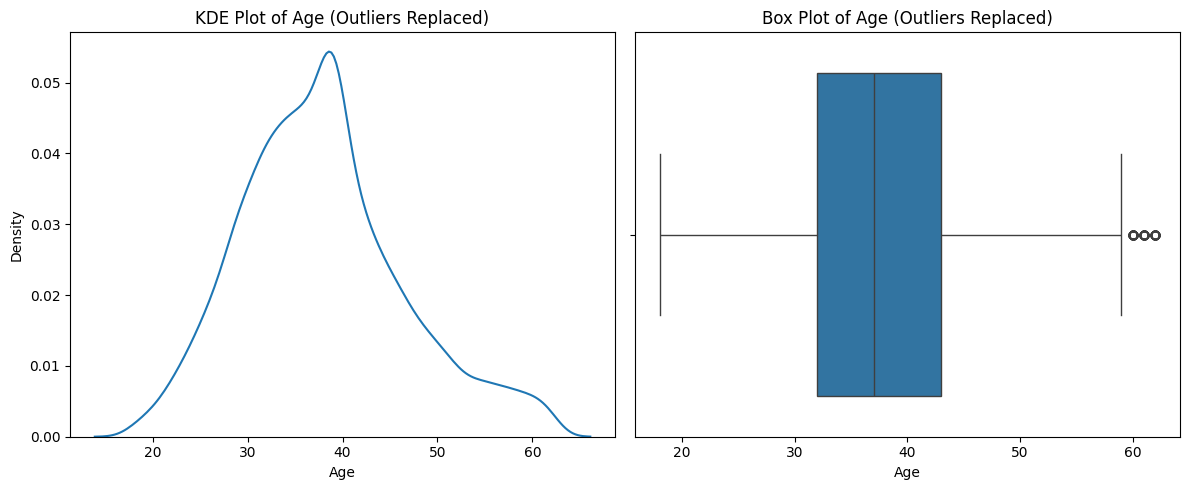

In [13]:
# Calculate the mean of 'Age'
mean_age = df['Age'].mean().round().astype(int)

# Calculate Q1, Q3, and IQR for Age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

# Define outlier bounds for Age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

print(f"Lower bound for Age outliers: {lower_bound_age}")
print(f"Upper bound for Age outliers: {upper_bound_age}")

# Display outliers before replacement
outliers_age_before_replacement = df[(df['Age'] < lower_bound_age) | (df['Age'] > upper_bound_age)]
print("\nOutliers in Age before replacement:")
display(outliers_age_before_replacement[['Age']].head())
print(f"Total number of outliers before replacement: {len(outliers_age_before_replacement)}")

# Replace outliers with the mean age
df['Age'] = np.where(df['Age'] < lower_bound_age, mean_age, df['Age'])
df['Age'] = np.where(df['Age'] > upper_bound_age, mean_age, df['Age'])

# Display outliers after replacement (should be empty or very few)
outliers_age_after_replacement = df[(df['Age'] < lower_bound_age) | (df['Age'] > upper_bound_age)]
print("\nOutliers in Age after replacement:")
display(outliers_age_after_replacement[['Age']].head())
print(f"Total number of outliers after replacement: {len(outliers_age_after_replacement)}")

# Visualize the distribution of Age after outlier treatment using KDE plot and box plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(df['Age'])
plt.title('KDE Plot of Age (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age (Outliers Replaced)')
plt.tight_layout()
plt.show()

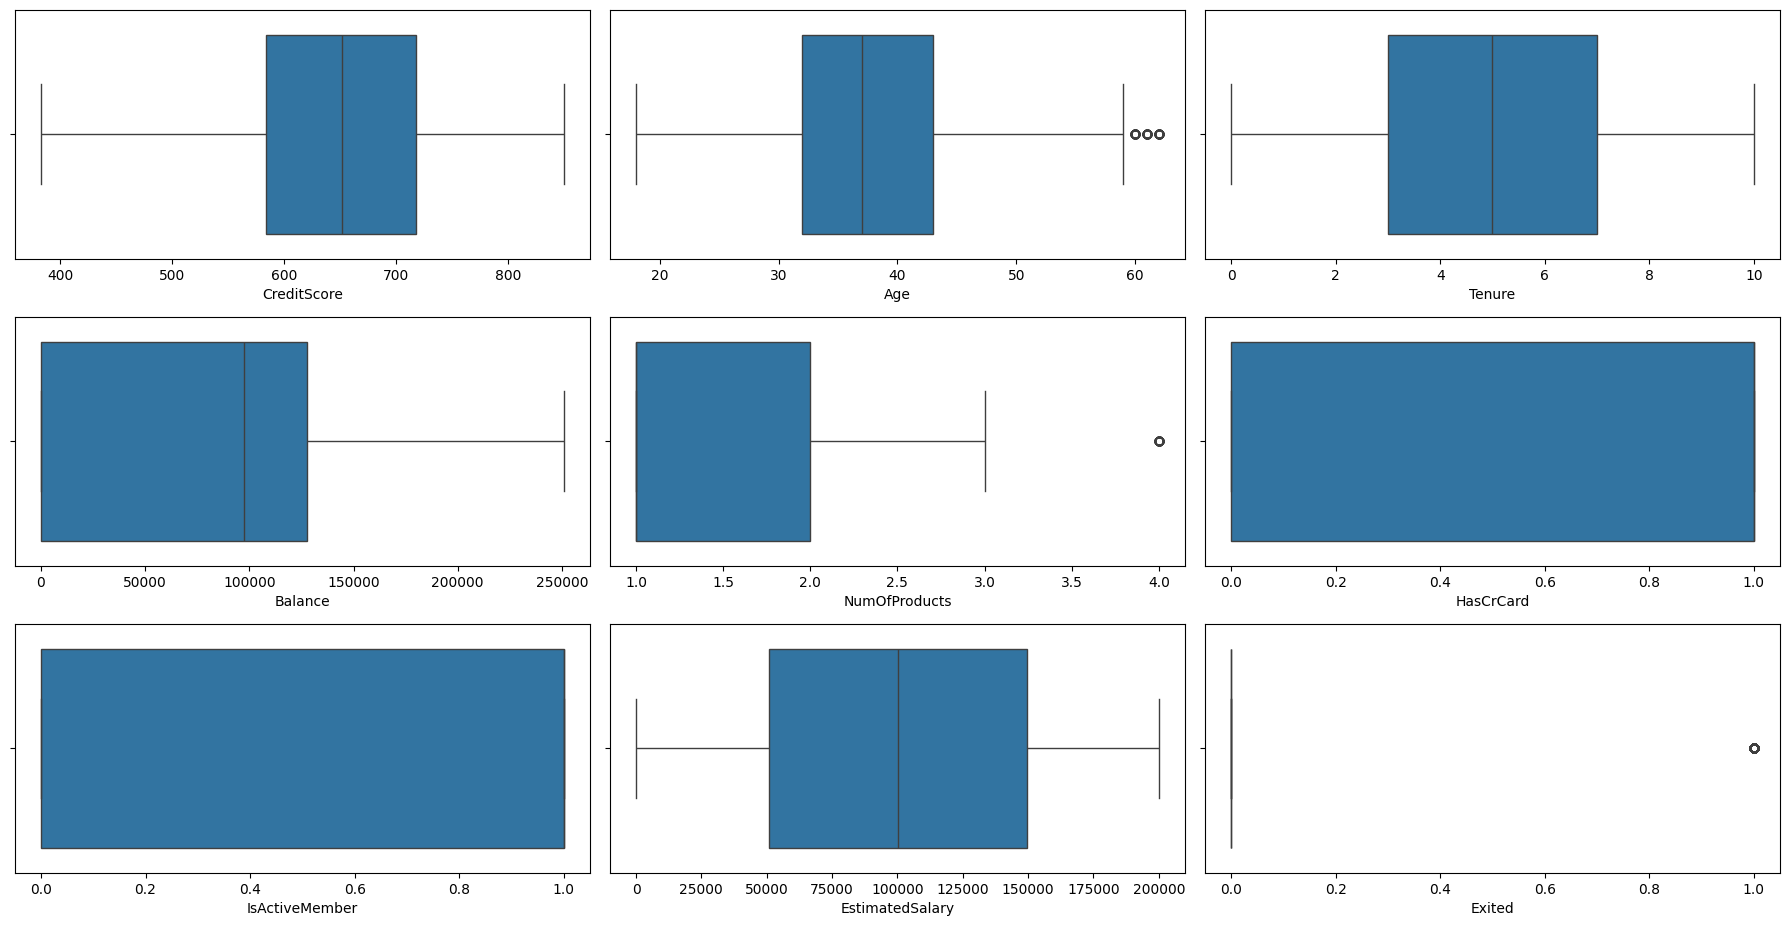

In [14]:
plt.figure(figsize=(18,12))
c=1
for i in df.describe().columns:
    plt.subplot(4,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

In [15]:
x=df.drop('Exited',axis=1)
y=df['Exited']

In [16]:
x=pd.get_dummies(x,drop_first=True,dtype=int)

In [17]:
from sklearn.model_selection import train_test_split as tts
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

# GridSearchCV

In [20]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [21]:
param={
    'criterion':['entropy','gini','log_loss'],
    'splitter':['best','random'],
    'max_depth':[3,4,5,6,7,8,9,10,11,12],
    'min_samples_split':[1,2,3,4]
                  }

In [22]:
GridCV=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param,
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [23]:
GridCV.fit(x_train,y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 4, ...], 'min_samples_split': [1, 2, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [24]:
GridCV.param_grid

{'criterion': ['entropy', 'gini', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'min_samples_split': [1, 2, 3, 4]}

In [25]:
GridCV.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_split': 2,
 'splitter': 'best'}

In [26]:
GridCV.best_score_

np.float64(0.8547499999999999)

# RandomizedSearchCV

In [27]:
param={
    'criterion':['entropy','gini','log_loss'],
    'splitter':['best','random'],
    'max_depth':[3,4,5,6,7,8,9,10,11,12],
    'min_samples_split':[1,2,3,4]
                  }

In [28]:
RandomCV = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param,
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [29]:
RandomCV.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 4, ...], 'min_samples_split': [1, 2, ...], 'splitter': ['best', 'random']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ve

In [30]:
RandomCV.param_distributions

{'criterion': ['entropy', 'gini', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'min_samples_split': [1, 2, 3, 4]}

In [31]:
RandomCV.best_params_

{'splitter': 'best',
 'min_samples_split': 2,
 'max_depth': 6,
 'criterion': 'gini'}

In [32]:
RandomCV.best_score_

np.float64(0.8522500000000001)